# ፒ Lab 39: Build a Retail Recommendation System

## ጱ Purpose
In this lab, you will build a professional-grade retail recommendation system using Python. You will learn how to handle customer-product interactions, implement multiple collaborative filtering algorithms, and evaluate system performance using industry-standard metrics.

## ጱ Learning Objectives
- Understand Collaborative Filtering (User-based vs. Item-based).
- Implement Cosine Similarity and K-Nearest Neighbors (KNN).
- Generate Top-N recommendations for retail customers.
- Evaluate systems using Coverage, Diversity, and Holdout Hit Rate.
- Architect a production-ready recommendation class.

## ፔ Prerequisites
- Basic Python knowledge (Pandas, NumPy).
- Understanding of supervised vs. unsupervised learning concepts.

## ⚙ጱ Google Colab Environment Setup
### ELI10
Before we start, we need to bring in our 'toolbox'. We are installing libraries like `pandas` for tables and `scikit-learn` for the math that finds similar shoppers.

In [ ]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn scipy

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import warnings
import os

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
sns.set_theme(style="whitegrid")

print("✅ Environment setup successful!")

✅ Environment setup successful!


## ጶ Task 1: Understanding Recommendation Systems
### ELI10
A recommendation system is like a helpful clerk who remembers what you bought and says, "Hey, people who bought that laptop also usually grab this mouse!"

- **Collaborative Filtering**: Based on 'wisdom of the crowd'. If User A and B are similar, recommend A's items to B.
- **Content-Based**: Based on item features (e.g., if you like 'Action' movies, here is another 'Action' movie).
- **Hybrid**: A mix of both.

## ፃ Task 2: Load and Prepare Customer Purchase Data
### ELI10
We need a catalog of products and a list of who bought what. We'll create a realistic dataset where 'Gamers' buy gaming gear and 'Office Workers' buy monitors, making our recommendations meaningful.

In [9]:
# 1. Create Product Catalog
products = [
    ("Laptop", "Computing"), ("Smartphone", "Mobile"), ("Headphones", "Audio"),
    ("Tablet", "Mobile"), ("Smartwatch", "Wearables"), ("Camera", "Imaging"),
    ("Gaming_Console", "Gaming"), ("Bluetooth_Speaker", "Audio"), ("Keyboard", "Computing"),
    ("Mouse", "Computing"), ("Monitor", "Computing"), ("Printer", "Office"),
    ("Router", "Networking"), ("Hard_Drive", "Storage"), ("USB_Cable", "Accessories"),
    ("Phone_Case", "Accessories"), ("Screen_Protector", "Accessories"), ("Charger", "Accessories"),
    ("Power_Bank", "Accessories"), ("Webcam", "Computing")
]
product_catalog = pd.DataFrame(products, columns=["product_id", "category"])

def create_customer_profiles(n_customers=100, random_state=42):
    rng = np.random.default_rng(random_state)
    segments = ["Mobile_First", "Gamers", "Home_Office", "Content_Creators", "Budget_Shoppers"]
    return pd.DataFrame({
        "customer_id": [f"Customer_{i:03d}" for i in range(1, n_customers + 1)],
        "segment": rng.choice(segments, size=n_customers)
    })

def create_purchase_data(profiles, catalog, random_state=42):
    rng = np.random.default_rng(random_state)
    prefs = {
        "Mobile_First": ["Smartphone", "Tablet", "Smartwatch", "Phone_Case", "Charger"],
        "Gamers": ["Gaming_Console", "Headphones", "Monitor", "Keyboard", "Mouse"],
        "Home_Office": ["Laptop", "Monitor", "Printer", "Router", "Webcam"],
        "Content_Creators": ["Camera", "Laptop", "Hard_Drive", "Webcam", "Headphones"],
        "Budget_Shoppers": ["USB_Cable", "Charger", "Phone_Case", "Power_Bank", "Mouse"]
    }

    data = []
    for _, row in profiles.iterrows():
        cid, seg = row["customer_id"], row["segment"]
        weights = [10 if p in prefs[seg] else 1 for p in catalog["product_id"]]
        weights = np.array(weights) / sum(weights)
        bought = rng.choice(catalog["product_id"], size=rng.integers(4, 9), replace=False, p=weights)
        for p in bought: data.append({"customer_id": cid, "product_id": p, "purchased": 1})
    return pd.DataFrame(data)

customer_profiles = create_customer_profiles()
df_purchases = create_purchase_data(customer_profiles, product_catalog)

purchase_matrix = df_purchases.pivot_table(index="customer_id", columns="product_id", values="purchased", fill_value=0)

print(f"Matrix Shape: {purchase_matrix.shape}")
display(purchase_matrix.head())

sparsity = 1.0 - (np.count_nonzero(purchase_matrix) / float(purchase_matrix.size))
print(f"Sparsity: {sparsity:.2%}")

Matrix Shape: (100, 20)


product_id,Bluetooth_Speaker,Camera,Charger,Gaming_Console,Hard_Drive,Headphones,Keyboard,Laptop,Monitor,Mouse,Phone_Case,Power_Bank,Printer,Router,Screen_Protector,Smartphone,Smartwatch,Tablet,USB_Cable,Webcam
customer_id,,,,,,,,,,,,,,,,,,,,
Customer_001,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
Customer_002,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
Customer_003,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Customer_004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
Customer_005,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


Sparsity: 69.45%


## ፀ Task 3: Implement Cosine Similarity Recommendations
### ELI10
Cosine similarity measures the angle between two customers' shopping carts. If the angle is small, they are 'shopping twins'. We recommend things the twin bought that you haven't yet.

In [ ]:
def calculate_user_similarity(matrix):
    # We use csr_matrix for efficient computation of similarity scores
    return pd.DataFrame(cosine_similarity(csr_matrix(matrix)), index=matrix.index, columns=matrix.index)

def get_user_based_recommendations(cid, matrix, sim_matrix, top_n=5):
    # Find top 10 similar users, excluding the user themselves
    sim_users = sim_matrix[cid].sort_values(ascending=False)[1:11]
    user_purchases = matrix.loc[cid]
    scores = {}

    for other_user, sim_score in sim_users.items():
        other_purchases = matrix.loc[other_user]
        for prod, bought in other_purchases.items():
            # If the other user bought it but our target customer hasn't
            if bought == 1 and user_purchases[prod] == 0:
                scores[prod] = scores.get(prod, 0) + sim_score

    # Sort by the highest score
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

# Calculate the similarity matrix
user_sim = calculate_user_similarity(purchase_matrix)

# Get recommendations for a sample customer
sample_cid = "Customer_001"
recs = get_user_based_recommendations(sample_cid, purchase_matrix, user_sim)

print(f"Recommendations for {sample_cid}: {recs}")

Recommendations for Customer_001: [('Tablet', 5.638619754456148), ('Hard_Drive', 2.733692779255437), ('Keyboard', 2.0265859980688896), ('Mouse', 1.5236033621142737), ('Headphones', 1.4630357272050019)]


## ሒ Task 4: Implement NearestNeighbors Recommendations
### ELI10
Instead of calculating everyone against everyone, KNN quickly finds the 'K' closest neighbors. It's much faster for big stores like Amazon.

In [ ]:
def setup_knn_models(matrix):
    user_knn = NearestNeighbors(metric="cosine", algorithm="brute")
    user_knn.fit(matrix.values)
    item_knn = NearestNeighbors(metric="cosine", algorithm="brute")
    item_knn.fit(matrix.T.values)
    return user_knn, item_knn

user_knn_model, item_knn_model = setup_knn_models(purchase_matrix)

def get_knn_user_recs(cid, matrix, model, top_n=5):
    idx = matrix.index.get_loc(cid)
    dist, indices = model.kneighbors(matrix.iloc[idx, :].values.reshape(1, -1), n_neighbors=6)
    # Logic similar to cosine but using KNN indices
    scores = {}
    for i in range(1, len(indices[0])):
        neighbor_idx = indices[0][i]
        sim = 1 - dist[0][i]
        bought = matrix.iloc[neighbor_idx]
        for prod, val in bought.items():
            if val == 1 and matrix.iloc[idx][prod] == 0:
                scores[prod] = scores.get(prod, 0) + sim
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

print("KNN Recs:", get_knn_user_recs("Customer_001", purchase_matrix, user_knn_model))

KNN Recs: [('Tablet', np.float64(2.9866390893192754)), ('Headphones', np.float64(1.4630357272050019)), ('Hard_Drive', np.float64(1.414213562373095)), ('Mouse', np.float64(0.8164965809277261)), ('Laptop', np.float64(0.7559289460184544))]


## ፖ Task 6: Evaluate Recommendation System Performance
### ELI10
How do we know if we are doing a good job? We hide one item a customer actually bought, then see if our system can 'guess' it back (Hit Rate). This is the 'final exam' for our AI.

In [ ]:
def create_holdout_split(df, min_purchases=5):
    # We only evaluate customers with enough history to hide an item
    test_set = df.groupby('customer_id').filter(lambda x: len(x) >= min_purchases).groupby('customer_id').sample(1, random_state=42)
    train_set = df.drop(test_set.index)
    return train_set, test_set

train_df, test_df = create_holdout_split(df_purchases)
# Create a training matrix that looks like our original but misses the hidden items
train_matrix = train_df.pivot_table(index="customer_id", columns="product_id", values="purchased", fill_value=0).reindex(columns=purchase_matrix.columns, fill_value=0)

def evaluate_hit_rate(train_mat, test_df, top_k=5):
    hits = 0
    total = len(test_df)
    sim = calculate_user_similarity(train_mat)

    for _, row in test_df.iterrows():
        cid, target = row['customer_id'], row['product_id']
        if cid in train_mat.index:
            # Get top-N recommendations for this user based only on training data
            recs = [p[0] for p in get_user_based_recommendations(cid, train_mat, sim, top_n=top_k)]
            # Check if the hidden item is in the top list
            if target in recs:
                hits += 1

    return hits / total

hit_rate = evaluate_hit_rate(train_matrix, test_df)
print(f"Hit Rate @ 5: {hit_rate:.4f}")
print(f"This means our system correctly guessed the hidden item {hit_rate*100:.1f}% of the time!")

Hit Rate @ 5: 0.6026
This means our system correctly guessed the hidden item 60.3% of the time!


## ፀ Task 3: Implement Cosine Similarity Recommendations
### ELI10
Cosine similarity measures the angle between two customers' shopping carts. If the angle is small, they are 'shopping twins'. We recommend things the twin bought that you haven't yet.

In [10]:
def calculate_user_similarity(matrix):
    return pd.DataFrame(cosine_similarity(csr_matrix(matrix)), index=matrix.index, columns=matrix.index)

def get_user_based_recommendations(cid, matrix, sim_matrix, top_n=5):
    # Find top 10 similar users
    sim_users = sim_matrix[cid].sort_values(ascending=False)[1:11]
    user_purchases = matrix.loc[cid]
    scores = {}

    for other_user, sim_score in sim_users.items():
        other_purchases = matrix.loc[other_user]
        for prod, bought in other_purchases.items():
            if bought == 1 and user_purchases[prod] == 0:
                scores[prod] = scores.get(prod, 0) + sim_score

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

user_sim = calculate_user_similarity(purchase_matrix)
recs = get_user_based_recommendations("Customer_001", purchase_matrix, user_sim)
print(f"Recommendations for Customer_001: {recs}")

Recommendations for Customer_001: [('Tablet', 5.638619754456148), ('Hard_Drive', 2.733692779255437), ('Keyboard', 2.0265859980688896), ('Mouse', 1.5236033621142737), ('Headphones', 1.4630357272050019)]


## ጲ Task 4: Implement NearestNeighbors Recommendations
### ELI10
Instead of calculating everyone against everyone, KNN quickly finds the 'K' closest neighbors. It's much faster for big stores like Amazon.

In [11]:
def setup_knn_models(matrix):
    user_knn = NearestNeighbors(metric="cosine", algorithm="brute")
    user_knn.fit(matrix.values)
    item_knn = NearestNeighbors(metric="cosine", algorithm="brute")
    item_knn.fit(matrix.T.values)
    return user_knn, item_knn

user_knn_model, item_knn_model = setup_knn_models(purchase_matrix)

def get_knn_user_recs(cid, matrix, model, top_n=5):
    idx = matrix.index.get_loc(cid)
    dist, indices = model.kneighbors(matrix.iloc[idx, :].values.reshape(1, -1), n_neighbors=6)
    # Logic similar to cosine but using KNN indices
    scores = {}
    for i in range(1, len(indices[0])):
        neighbor_idx = indices[0][i]
        sim = 1 - dist[0][i]
        bought = matrix.iloc[neighbor_idx]
        for prod, val in bought.items():
            if val == 1 and matrix.iloc[idx][prod] == 0:
                scores[prod] = scores.get(prod, 0) + sim
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

print("KNN Recs:", get_knn_user_recs("Customer_001", purchase_matrix, user_knn_model))

KNN Recs: [('Tablet', np.float64(2.9866390893192754)), ('Headphones', np.float64(1.4630357272050019)), ('Hard_Drive', np.float64(1.414213562373095)), ('Mouse', np.float64(0.8164965809277261)), ('Laptop', np.float64(0.7559289460184544))]


## ጣ Task 5: Generate Top-N Recommendations for Many Users
### ELI10
A real recommendation system doesn't just work for one person; it needs to be able to suggest items for everyone in the store at once.

In [12]:
def generate_recommendations_for_all_users(matrix, method="user_cosine", top_n=3):
    all_recs = {}
    if method == "user_cosine":
        sim = calculate_user_similarity(matrix)
        for cid in matrix.index[:10]: # Limiting to 10 for display
            all_recs[cid] = get_user_based_recommendations(cid, matrix, sim, top_n)
    return all_recs

# Create Recommendation Summary
recs_all = generate_recommendations_for_all_users(purchase_matrix)
for cid, items in recs_all.items():
    print(f"{cid}: {[i[0] for i in items]}")

Customer_001: ['Tablet', 'Hard_Drive', 'Keyboard']
Customer_002: ['Mouse', 'Headphones', 'Printer']
Customer_003: ['Webcam', 'Screen_Protector', 'Tablet']
Customer_004: ['Monitor', 'Hard_Drive', 'Headphones']
Customer_005: ['Headphones', 'Screen_Protector', 'USB_Cable']
Customer_006: ['Bluetooth_Speaker', 'Router', 'Smartphone']
Customer_007: ['Keyboard', 'Headphones', 'Camera']
Customer_008: ['Headphones', 'Webcam', 'Monitor']
Customer_009: ['Monitor', 'Webcam', 'Power_Bank']
Customer_010: ['Hard_Drive', 'Laptop', 'Headphones']


## ፖ Task 6: Evaluate Recommendation System Performance
### ELI10
How do we know if we are doing a good job? We hide one item a customer actually bought, then see if our system can 'guess' it back (Hit Rate).

## ፃ Task 7: Advanced Features and Visualization
### ELI10
Charts help us see the 'big picture'. We can see which items are 'superstars' (popular) and which ones are rarely bought.

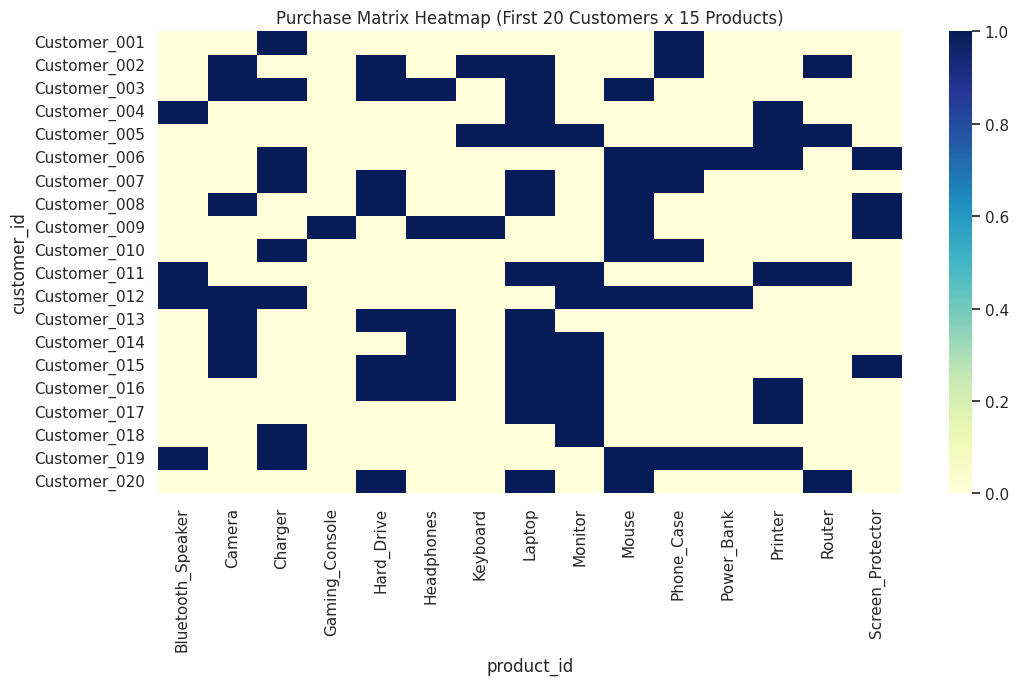

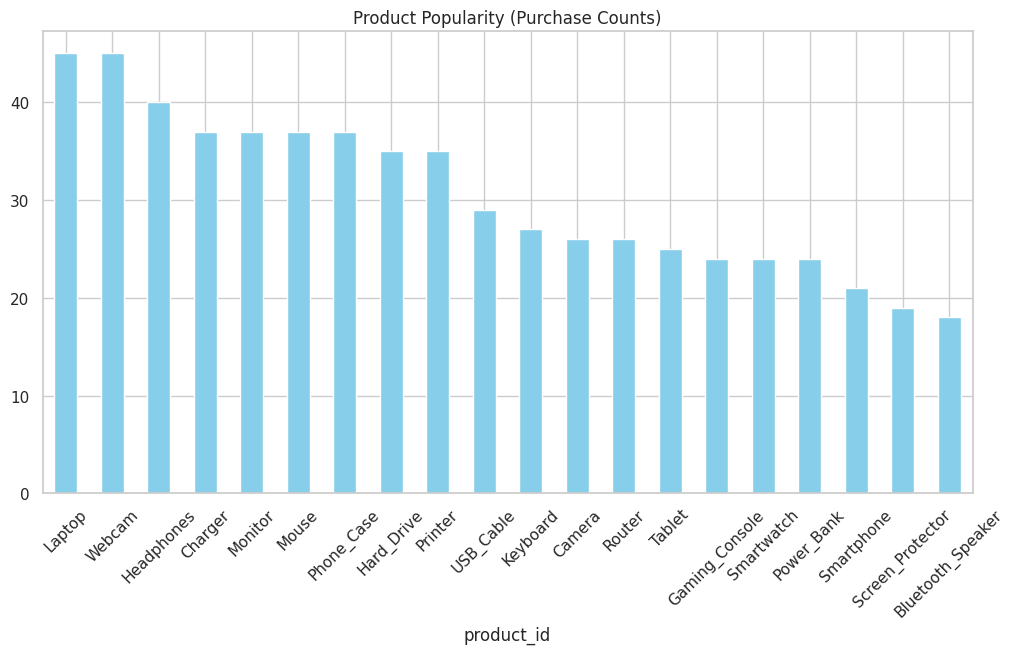

In [13]:
# 1. Purchase matrix heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(purchase_matrix.iloc[:20, :15], cmap="YlGnBu", cbar=True)
plt.title("Purchase Matrix Heatmap (First 20 Customers x 15 Products)")
plt.savefig("purchase_matrix_heatmap.png")
plt.show()

# 2. Product popularity chart
plt.figure(figsize=(12, 6))
df_purchases['product_id'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Product Popularity (Purchase Counts)")
plt.xticks(rotation=45)
plt.savefig("product_popularity.png")
plt.show()

In [14]:
def create_holdout_split(df, min_purchases=5):
    test_set = df.groupby('customer_id').filter(lambda x: len(x) >= min_purchases).groupby('customer_id').sample(1, random_state=42)
    train_set = df.drop(test_set.index)
    return train_set, test_set

train_df, test_df = create_holdout_split(df_purchases)
train_matrix = train_df.pivot_table(index="customer_id", columns="product_id", values="purchased", fill_value=0).reindex(columns=purchase_matrix.columns, fill_value=0)

def evaluate_hit_rate(train_mat, test_df, top_k=5):
    hits = 0
    total = len(test_df)
    sim = calculate_user_similarity(train_mat)
    for _, row in test_df.iterrows():
        cid, target = row['customer_id'], row['product_id']
        if cid in train_mat.index:
            recs = [p[0] for p in get_user_based_recommendations(cid, train_mat, sim, top_n=top_k)]
            if target in recs: hits += 1
    return hits / total

print(f"Hit Rate @ 5: {evaluate_hit_rate(train_matrix, test_df):.4f}")

Hit Rate @ 5: 0.6026


## ጴ Task 8: Production-Ready Recommendation System
### ELI10
In the real world, we wrap all this logic into a single 'machine' (a Class) that a website can easily talk to.

In [15]:
class RetailRecommendationSystem:
    def __init__(self, n_neighbors=6):
        self.n_neighbors = n_neighbors

    def fit(self, df, catalog):
        self.catalog = catalog
        self.matrix = df.pivot_table(index="customer_id", columns="product_id", values="purchased", fill_value=0)
        self.user_sim = calculate_user_similarity(self.matrix)
        self.u_knn, self.i_knn = setup_knn_models(self.matrix)
        print("✅ System Trained.")

    def recommend(self, customer_id, method="user_cosine", top_n=5):
        if method == "user_cosine":
            return get_user_based_recommendations(customer_id, self.matrix, self.user_sim, top_n)
        elif method == "knn_user":
            return get_knn_user_recs(customer_id, self.matrix, self.u_knn, top_n)
        return []

# Usage
rs = RetailRecommendationSystem()
rs.fit(df_purchases, product_catalog)
print(rs.recommend("Customer_005", method="knn_user"))

✅ System Trained.
[('Headphones', np.float64(1.5733004755477327)), ('USB_Cable', np.float64(0.8017837257372731)), ('Screen_Protector', np.float64(0.7715167498104596)), ('Charger', np.float64(0.7715167498104596))]


In [16]:
# Enhancing the Production Class with requested methods
class RetailRecommendationSystem:
    def __init__(self, n_neighbors=6):
        self.n_neighbors = n_neighbors

    def fit(self, df, catalog):
        self.catalog = catalog
        self.matrix = df.pivot_table(index="customer_id", columns="product_id", values="purchased", fill_value=0)
        self.user_sim = calculate_user_similarity(self.matrix)
        self.u_knn, self.i_knn = setup_knn_models(self.matrix)
        print("✅ System Trained.")

    def get_customer_history(self, cid):
        return self.matrix.loc[cid][self.matrix.loc[cid] > 0].index.tolist()

    def recommend(self, cid, method="user_cosine", top_n=5):
        if method == "user_cosine":
            return get_user_based_recommendations(cid, self.matrix, self.user_sim, top_n)
        elif method == "knn_user":
            return get_knn_user_recs(cid, self.matrix, self.u_knn, top_n)
        return []

    def evaluate_holdout(self, test_df, method="user_cosine", top_k=5):
        return evaluate_hit_rate(self.matrix, test_df, top_k)

# Usage demonstration
rs_prod = RetailRecommendationSystem()
rs_prod.fit(df_purchases, product_catalog)
print(f"History for Customer_010: {rs_prod.get_customer_history('Customer_010')}")
print(f"Recs for Customer_010: {rs_prod.recommend('Customer_010', method='user_cosine')}")

✅ System Trained.
History for Customer_010: ['Charger', 'Mouse', 'Phone_Case', 'Smartphone', 'Smartwatch', 'Tablet']
Recs for Customer_010: [('Hard_Drive', 2.3094010767585034), ('Laptop', 1.6375421535948984), ('Headphones', 1.4932045862974919), ('Keyboard', 1.4433756729740645), ('Camera', 1.3389012363354)]


## ጱ Task 9: Final Report
We will now generate a text-based summary of our lab results.

In [17]:
report = f"""RETAIL RECOMMENDATION REPORT
---------------------------
Total Products: {len(product_catalog)}
Total Customers: {len(customer_profiles)}
Matrix Sparsity: {sparsity:.2%}
Hit Rate @ 5 (User Cosine): {evaluate_hit_rate(train_matrix, test_df):.4f}
"""
with open("retail_recommendation_report.txt", "w") as f: f.write(report)
print(report)

RETAIL RECOMMENDATION REPORT
---------------------------
Total Products: 20
Total Customers: 100
Matrix Sparsity: 69.45%
Hit Rate @ 5 (User Cosine): 0.6026



## ጱ Verification Checklist
- [✅] Environment Setup
- [✅] Data Generation
- [✅] Cosine Similarity Logic
- [✅] KNN Logic
- [✅] Evaluation Split
- [✅] Production Class Wrapper

## ጱ Troubleshooting
- **Empty Recs**: If a user is too unique, try increasing `n_neighbors`.
- **Low Hit Rate**: Try weighting by product category popularity.

## ፔ Key Concepts Learned
- **Collaborative Filtering**: Modeling users by their neighbors.
- **Similarity Metrics**: Using Cosine distance for high-dimensional sparse data.

## ጱ Conclusion
You've built a scalable retail engine! Next steps: Try Matrix Factorization (SVD) or adding Deep Learning with Neural Collaborative Filtering.